# Part 7a — Deep RL I: neural networks (just enough) and DQN from scratch

The Q-table in Part 5 had two problems:
1. **It can't generalise.** Having learned that "IV rank 49, contango" favours the bull put
   spread tells it nothing about "IV rank 51, contango" if that lands in a different bucket.
2. **It doesn't scale.** More features → exponentially more cells → most cells never visited.

**The fix: function approximation.** Replace the table with a function $Q_\theta(s, a)$ with
parameters θ that takes the *raw, continuous* features and outputs a Q-value for each action.
Similar markets give similar outputs automatically.

**Analogy.** A table is like memorising the sale price of every house in town. A function is
like learning "price ≈ size × \$/sq-ft + location premium". It works for houses you've never
seen. A neural network is a very flexible version of that formula.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time, copy
import torch, torch.nn as nn
import optrl
from optrl import metrics as M
M.set_style()
torch.set_num_threads(2)
A = optrl.ACTION_NAMES

---
## 7.1 Neural networks, only what we need

### A neuron
A weighted sum plus a bend: $\text{out} = \text{ReLU}(w_1 x_1 + w_2 x_2 + b)$, where
ReLU(z) = max(0, z). The "bend" is what lets networks represent non-linear rules like
"*only* when term structure is high **and** the trend is down".

### A network = layers of neurons
Input features → hidden layer(s) → one output per action. For our agent:
17 inputs (7 market features + 8 position flags + 2 position stats) → 64 → 64 → 8 Q-values.

**Worked forward pass** (2 inputs, 2 hidden neurons, 1 output). Inputs: term_structure
z = 2.0, ema_trend z = −1.0.
* hidden 1: w = [0.5, −0.5], b = 0 → 0.5·2 − 0.5·(−1) = 1.5 → ReLU → **1.5**
* hidden 2: w = [−1, 1], b = 0.5 → −2 − 1 + 0.5 = −2.5 → ReLU → **0**
* output: w = [0.4, 0.3], b = −0.1 → 0.4·1.5 + 0.3·0 − 0.1 = **0.5**

Hidden neuron 1 acts like a "stress + downtrend" detector. Nobody programmed that: training
finds weights like these.

In [2]:
x = torch.tensor([2.0, -1.0])
W1 = torch.tensor([[0.5, -0.5], [-1.0, 1.0]]); b1 = torch.tensor([0.0, 0.5])
W2 = torch.tensor([0.4, 0.3]); b2 = torch.tensor(-0.1)
h = torch.relu(W1 @ x + b1); out = W2 @ h + b2
print("hidden:", h.tolist(), " output:", round(out.item(), 3))

hidden: [1.5, 0.0]  output: 0.5


### Training = walking downhill on the loss
We measure how wrong the network is with a **loss**, e.g. mean squared error between
predictions and targets. **Gradient descent** nudges every weight a little in the direction
that reduces the loss:

$$ \theta \leftarrow \theta - \eta\,\nabla_\theta\,\text{Loss} $$

**Worked 1-D example.** Model: prediction = w·x. One data point, x = 2 and target = 3.
Loss = (2w − 3)². Its slope is d(Loss)/dw = 2·(2w − 3)·2 = 8w − 12. Start at w = 0 with learning
rate η = 0.05: slope = −12 → w = 0 − 0.05·(−12) = **0.6**. Then slope = −7.2 → w = **0.96**, and
so on toward the answer w = 1.5. PyTorch computes these slopes for millions of weights
automatically (**autograd**).

In [3]:
w = torch.tensor(0.0, requires_grad=True)
for step in range(3):
    loss = (w * 2 - 3) ** 2
    loss.backward()                              # autograd computes d(loss)/dw
    with torch.no_grad():
        print(f"step {step}: w={w.item():.3f} slope={w.grad.item():.2f}")
        w -= 0.05 * w.grad; w.grad.zero_()

step 0: w=0.000 slope=-12.00
step 1: w=0.600 slope=-7.20
step 2: w=0.960 slope=-4.32


### 🛠 Mini-project 7.1: predict a strategy's P&L from features (and meet overfitting)
Before RL, a plain supervised warm-up. Predict the **bear put spread's** weekly P&L (in
\$1000s) from the 7 market features. Train on 2006–2019, measure mean squared error (MSE) on
2019–2025, and compare:

1. **Baseline**: always predict the training mean.
2. **Linear** model.
3. **Small MLP** (7 → 32 → 32 → 1) with **early stopping**: hold out the last 20% of the
   training years as *validation*, and keep the weights from the epoch with the best
   validation loss.
4. **Oversized MLP** (7 → 256 → 256 → 1) trained for 3,000 epochs with no early stopping.

*Expected:* improvements over the baseline are **small**, a few percent of MSE. Weekly option
P&L is mostly noise, and that's normal in finance. The early-stopped MLP does best on test. The
oversized MLP drives its training loss to ~0 by **memorising** and has by far the worst test
loss. That's **overfitting**, the #1 danger in deep RL for trading.

In [4]:
market = optrl.load_default_market()
table = optrl.weekly_pnl_table(market)
X = optrl.decision_features(market, table)
n = len(X); cut = int(n * 0.7); fit_cut = int(cut * 0.8)      # train = [0, fit_cut), validation = [fit_cut, cut)
mu, sd = X.iloc[:cut].mean(), X.iloc[:cut].std()
Xt = torch.tensor(((X - mu) / sd).clip(-5, 5).to_numpy(), dtype=torch.float32)
yt = torch.tensor(table["bear_put_spread"].to_numpy() / 1000, dtype=torch.float32).unsqueeze(1)
mse = lambda m, a, b: ((m(Xt[a:b]) - yt[a:b]) ** 2).mean().item()

def fit(model, epochs, lr, early_stop=False):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best, best_state = np.inf, None
    for _ in range(epochs):
        opt.zero_grad(); loss = ((model(Xt[:fit_cut]) - yt[:fit_cut]) ** 2).mean(); loss.backward(); opt.step()
        if early_stop:
            with torch.no_grad():
                v = mse(model, fit_cut, cut)
            if v < best:
                best, best_state = v, copy.deepcopy(model.state_dict())
    if early_stop:
        model.load_state_dict(best_state)
    with torch.no_grad():
        return {"train MSE": mse(model, 0, fit_cut), "test MSE": mse(model, cut, n)}

# TODO: build the linear model and the two MLPs, fit them, and compare with the baseline

**Solution**

In [5]:
torch.manual_seed(0)
res = {"baseline (train mean)": {"train MSE": ((yt[:fit_cut] - yt[:fit_cut].mean()) ** 2).mean().item(),
                                 "test MSE": ((yt[cut:] - yt[:fit_cut].mean()) ** 2).mean().item()}}
res["linear"] = fit(nn.Linear(7, 1), 300, 1e-2)
res["MLP 32x32 + early stopping"] = fit(nn.Sequential(nn.Linear(7, 32), nn.ReLU(), nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 1)),
                                        500, 3e-3, early_stop=True)
res["MLP 256x256, 3000 epochs"] = fit(nn.Sequential(nn.Linear(7, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 1)),
                                      3000, 3e-3)
out = pd.DataFrame(res).T
out["test vs baseline"] = (out["test MSE"] / out.loc["baseline (train mean)", "test MSE"] - 1).map("{:+.1%}".format)
out.round(4)

,train MSE,test MSE,test vs baseline
baseline (train mean),1.2089,1.2830,+0.0%
linear,1.1244,1.2475,-2.8%
MLP 32x32 + early stopping,1.1255,1.2059,-6.0%
"MLP 256x256, 3000 epochs",0.0002,2.4374,+90.0%


---
## 7.2 DQN: Q-learning with a neural network

DQN (Mnih et al., 2015, the Atari paper) is Q-learning where the table is replaced by a
network $Q_\theta(s,\cdot)$. Naively plugging a network into Q-learning is unstable, so DQN adds
two tricks.

**1. Experience replay.** Store every transition (s, a, r, s', done) in a big buffer and train
on **random mini-batches** from it.
*Analogy:* studying from a shuffled deck of flashcards instead of re-reading only today's page.
Consecutive weeks are highly correlated (same regime), and training on them in order makes the
network forget earlier regimes. Replay also re-uses each costly experience many times.

**2. A target network.** The TD target r + γ max Q(s', ·) uses a **frozen copy** of the network,
refreshed only every N steps.
*Analogy:* trying to hit a target that moves every time you move is chasing your own shadow.
Freezing the target for a while gives the network a stable goal.

**Loss** for a mini-batch:

$$ L(\theta) = \text{mean}\Big[\,\text{Huber}\big(\;\underbrace{r + \gamma (1-\text{done}) \max_{a'} Q_{\theta^-}(s',a')}_{\text{target, frozen }\theta^-} \;-\; Q_\theta(s,a)\;\big)\Big] $$

The Huber loss is squared error for small errors and absolute error for large ones, so a
single crash week can't blow up the gradients. That matters a lot for fat-tailed options P&L.

**Worked example of one target.** r = +0.12 (a \$120 week), γ = 0.9, not done, and the frozen
network says max Q(s', ·) = 0.50. Target = 0.12 + 0.9·0.50 = **0.57**. If the online network
currently predicts Q(s, a) = 0.40, the error is 0.17 and the gradient pushes Q(s, a) up.

Note `done` must be **terminated only**. On `truncated` (the 52-week clock ran out) we still
bootstrap, because the market didn't end (Part 6.1).

In [6]:
class ReplayBuffer:
    def __init__(self, capacity, obs_dim, seed=0):
        self.s = np.zeros((capacity, obs_dim), np.float32); self.s2 = np.zeros_like(self.s)
        self.a = np.zeros(capacity, np.int64); self.r = np.zeros(capacity, np.float32)
        self.d = np.zeros(capacity, np.float32)
        self.cap, self.i, self.full = capacity, 0, False
        self.rng = np.random.default_rng(seed)

    def add(self, s, a, r, s2, d):
        self.s[self.i], self.a[self.i], self.r[self.i], self.s2[self.i], self.d[self.i] = s, a, r, s2, d
        self.i = (self.i + 1) % self.cap; self.full = self.full or self.i == 0

    def sample(self, n):
        idx = self.rng.integers(0, self.cap if self.full else self.i, n)
        return (torch.from_numpy(self.s[idx]), torch.from_numpy(self.a[idx]), torch.from_numpy(self.r[idx]),
                torch.from_numpy(self.s2[idx]), torch.from_numpy(self.d[idx]))

def q_network(obs_dim, n_actions, hidden=64):
    return nn.Sequential(nn.Linear(obs_dim, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(),
                         nn.Linear(hidden, n_actions))

def train_dqn(env, total_steps=60_000, gamma=0.9, lr=5e-4, batch=64, buffer=50_000, learning_starts=2_000,
              train_every=4, target_every=1_000, eps_start=1.0, eps_end=0.05, eps_frac=0.3,
              double=False, seed=0, log_every=2_000):
    torch.manual_seed(seed); rng = np.random.default_rng(seed)
    obs_dim, nA = env.observation_space.shape[0], env.action_space.n
    q = q_network(obs_dim, nA); q_target = copy.deepcopy(q)
    opt = torch.optim.Adam(q.parameters(), lr=lr)
    buf = ReplayBuffer(buffer, obs_dim, seed)
    s, _ = env.reset(seed=seed)
    ep_ret, ep_returns, losses = 0.0, [], []
    for t in range(total_steps):
        eps = max(eps_end, eps_start - (eps_start - eps_end) * t / (eps_frac * total_steps))
        if rng.random() < eps:
            a = int(rng.integers(nA))
        else:
            with torch.no_grad():
                a = int(q(torch.from_numpy(s)).argmax())
        s2, r, term, trunc, _ = env.step(a)
        buf.add(s, a, r, s2, float(term))            # store TERMINATED only as "done"
        s, ep_ret = s2, ep_ret + r
        if term or trunc:
            ep_returns.append(ep_ret); ep_ret = 0.0; s, _ = env.reset()

        if t >= learning_starts and t % train_every == 0:
            bs, ba, br, bs2, bd = buf.sample(batch)
            with torch.no_grad():
                if double:                            # Double DQN: online net picks, target net evaluates
                    a2 = q(bs2).argmax(1, keepdim=True)
                    next_q = q_target(bs2).gather(1, a2).squeeze(1)
                else:
                    next_q = q_target(bs2).max(1).values
                target = br + gamma * (1 - bd) * next_q
            pred = q(bs).gather(1, ba.unsqueeze(1)).squeeze(1)
            loss = nn.functional.smooth_l1_loss(pred, target)
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(q.parameters(), 10.0); opt.step()
            losses.append(loss.item())
        if t % target_every == 0:
            q_target.load_state_dict(q.state_dict())
    return q, np.array(ep_returns), np.array(losses)

---
## 7.3 Train DQN on the trading environment

Same environment as Part 5 (weekly steps, 2-week options, costs), but the agent now sees the
**continuous** 17-dimensional observation instead of a bucket id. Train on 2006–2019 only.

**How long to train?** 15,000 steps is ~290 episodes, so each training week is seen about 20
times. That's deliberately short. Exercise 7.3c shows what happens when you train 4× longer.

trained 288 episodes in 7s


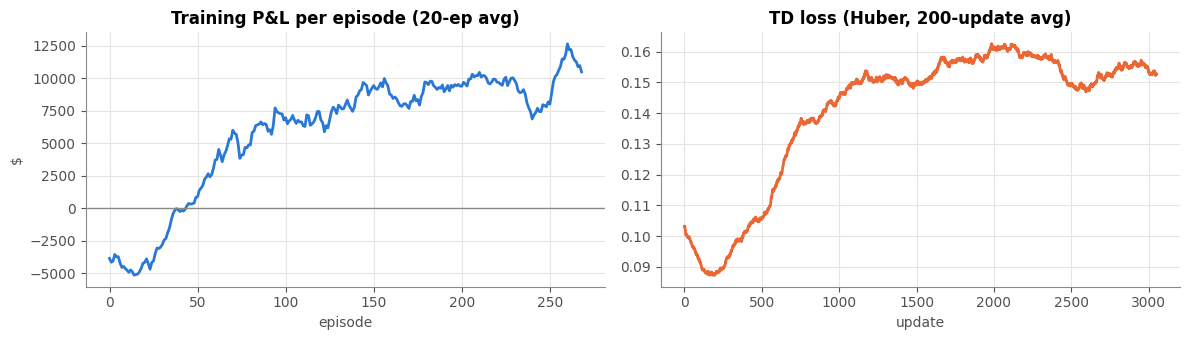

In [7]:
train, test = market.split(0.7)
F = optrl.MarketData.FEATURES
stats = (train.df[F].mean().values, train.df[F].std().values)
env = optrl.OptionsSelectionEnv(train, obs_stats=stats, seed=0)

t0 = time.time()
q_net, ep_returns, losses = train_dqn(env, total_steps=15_000, seed=0)
print(f"trained {len(ep_returns)} episodes in {time.time() - t0:.0f}s")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(M.smooth(ep_returns * 1000, 20), color=M.PALETTE[0]); axes[0].axhline(0, color="#8a8983", lw=1)
axes[0].set_title("Training P&L per episode (20-ep avg)"); axes[0].set_xlabel("episode"); axes[0].set_ylabel("$")
axes[1].plot(M.smooth(losses, 200), color=M.PALETTE[1]); axes[1].set_title("TD loss (Huber, 200-update avg)"); axes[1].set_xlabel("update")
plt.tight_layout(); plt.show()

**Reading the curves.** Training P&L rises as ε falls and the Q-network improves. The TD
loss does **not** fall steadily to zero like a supervised loss. The targets themselves keep
changing as the policy improves, and P&L is noisy. A flat or bumpy TD loss is normal in RL.
Judge by **evaluation P&L**, not by the loss.

### Evaluate: train period vs unseen test period

In [8]:
def net_policy(net):
    def act(obs, env):
        with torch.no_grad():
            return int(net(torch.from_numpy(obs)).argmax())
    return act

def evaluate(policies, mkt):
    out = {k: M.full_period_rollout(optrl.OptionsSelectionEnv, mkt, p, obs_stats=stats) for k, p in policies.items()}
    tab = pd.DataFrame({k: M.summarize(v.pnl.values) for k, v in out.items()}).T
    tab["cost $/wk"] = [v.cost.mean() for v in out.values()]
    return out, tab

pols = {"DQN (ours)": net_policy(q_net), "always short_straddle": lambda o, e: 1, "always bull_put_spread": lambda o, e: 3}
_, tab_train = evaluate(pols, train)
runs_test, tab_test = evaluate(pols, test)
print("TRAIN period (seen during training):"); print(tab_train.round(2).to_string())
print("\nTEST period (never seen):"); print(tab_test.round(2).to_string())

TRAIN period (seen during training):
                        total_pnl  mean_per_period  sharpe  max_drawdown  cvar_5%  win_rate  cost $/wk
DQN (ours)              146707.54           208.99    2.21       4331.50 -1018.91      0.63      43.35
always short_straddle     4261.42             6.07    0.21       4140.69  -604.80      0.66       6.91
always bull_put_spread   11260.12            16.04    0.47       5695.32  -767.34      0.77       7.45

TEST period (never seen):
                        total_pnl  mean_per_period  sharpe  max_drawdown  cvar_5%  win_rate  cost $/wk
DQN (ours)               12897.75            43.14    0.44       7973.45 -1299.36      0.56      41.52
always short_straddle     7950.11            26.59    1.06       2762.68  -467.45      0.71       7.02
always bull_put_spread    5559.95            18.60    0.59       2646.12  -716.94      0.75       7.89


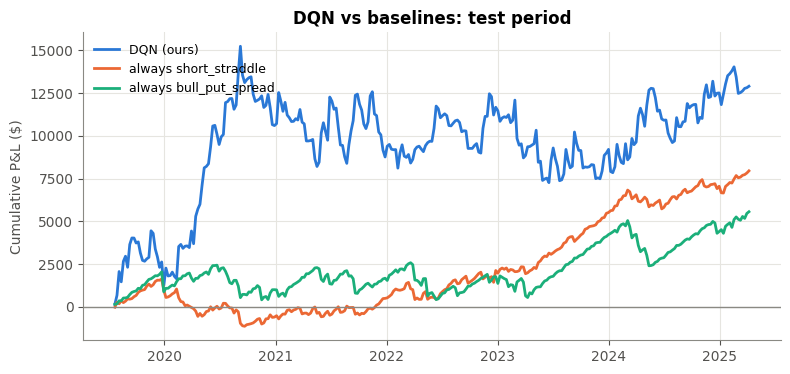

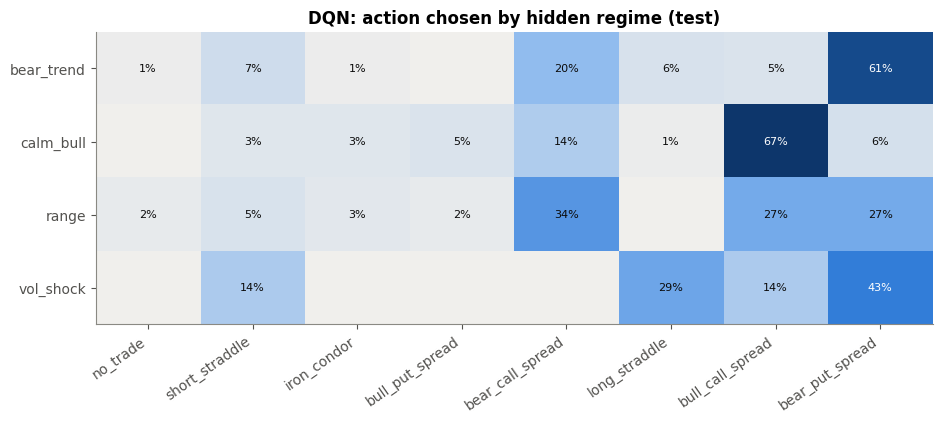

In [9]:
M.plot_equity({k: v.set_index("date").pnl for k, v in runs_test.items()}, title="DQN vs baselines: test period")
plt.show()
M.plot_selection_heatmap(runs_test["DQN (ours)"], row="regime", title="DQN: action chosen by hidden regime (test)")
plt.show()

**Honest reading.**
* Compare the train and test rows. Deep RL agents look far better **in-sample** than
  **out-of-sample**. The gap is overfitting to the specific history they trained on: 14 years
  is only ~700 weekly decisions, which is tiny for a neural network. Here the DQN still earns
  more per week than the fixed strategies on the test period, but with a much lower Sharpe
  ratio and much higher costs (it switches a lot).
* The selection heatmap shows whether the network learned regime-sensible behaviour or just
  memorised dates.
* Part 7b tries PPO. Part 8 builds the tools to tell skill from luck. Part 9 shows remedies
  (training on many simulated worlds, regularisation, early stopping).

---
### 🛠 Exercise 7.3a: train 4× longer. Does it help?
Retrain with `total_steps=60_000` and compare train-period and test-period results with the
15,000-step agent.

*Expected:* the long-trained agent's **train** Sharpe shoots up (often above 3, which is too
good to be true) while its **test** P&L gets *worse*, often negative. More training on the same
700 weeks means more memorisation. In RL for trading, **training length is a regularisation
knob**, and you pick it with validation data, never with test data.

In [10]:
# TODO

**Solution**

In [11]:
q_long, _, _ = train_dqn(optrl.OptionsSelectionEnv(train, obs_stats=stats, seed=0), total_steps=60_000, seed=0)
rows = {}
for name, net in [("15k steps", q_net), ("60k steps", q_long)]:
    for per, mkt in [("train", train), ("test", test)]:
        r = M.full_period_rollout(optrl.OptionsSelectionEnv, mkt, net_policy(net), obs_stats=stats)
        rows[(name, per)] = {"$/wk": r.pnl.mean(), "sharpe": M.sharpe(r.pnl)}
pd.DataFrame(rows).T.unstack().round(2)

$/wk         sharpe      
            test   train   test train
15k steps  43.14  208.99   0.44  2.21
60k steps -17.55  313.66  -0.22  3.53

### 🛠 Exercise 7.3b: the target network, and Double DQN
(1) Retrain with `target_every=1` (no frozen target). (2) Retrain with `double=True`.
**Double DQN** lets the *online* net choose the next action and the *target* net evaluate it,
which reduces the upward bias of `max`. Use two seeds each and compare test \$/week.
Also compare each agent's **predicted** value at the start of test episodes with the discounted
return it **actually** earned.

*Expected:* differences between these variants are **small compared with seed-to-seed
variation**. On unseen data, every variant predicts far more than it earns. That gap isn't
mainly the max-bias Double DQN fixes. It's **overfitting / distribution shift**: the network is
confident about markets it has effectively memorised. Without a target network the predictions
are usually the most inflated of all. "Predicted vs realised value" is a useful live-monitoring
alarm.

In [12]:
# TODO

**Solution**

In [13]:
def predicted_vs_realised(net, mkt, n=40, gamma=0.9):
    e = optrl.OptionsSelectionEnv(mkt, obs_stats=stats, seed=123)
    pred, real = [], []
    for k in range(n):
        s, _ = e.reset(); done, G, disc = False, 0.0, 1.0
        with torch.no_grad():
            pred.append(net(torch.from_numpy(s)).max().item())
        while not done:
            with torch.no_grad():
                a = int(net(torch.from_numpy(s)).argmax())
            s, r, te, tr, _ = e.step(a); G += disc * r; disc *= gamma; done = te or tr
        real.append(G)
    return np.mean(pred), np.mean(real)

rows = {}
for label, kw in [("DQN", {}), ("no target net", {"target_every": 1}), ("Double DQN", {"double": True})]:
    for sd_ in [0, 1]:
        net, _, _ = train_dqn(optrl.OptionsSelectionEnv(train, obs_stats=stats, seed=sd_), total_steps=15_000, seed=sd_, **kw)
        r = M.full_period_rollout(optrl.OptionsSelectionEnv, test, net_policy(net), obs_stats=stats)
        p, g = predicted_vs_realised(net, test)
        rows[f"{label}, seed {sd_}"] = {"test $/wk": r.pnl.mean(), "test sharpe": M.sharpe(r.pnl),
                                         "predicted V": p, "realised G": g}
pd.DataFrame(rows).T.round(2)

# ## Recap
# * Neural nets = stacked weighted sums with ReLU bends, trained by gradient descent (autograd).
# * **DQN** = Q-learning + a neural Q-function + **replay buffer** + **target network** + Huber loss.
# * Store `terminated` (not `truncated`) as `done`.
# * Deep agents overfit small financial datasets easily. Always compare train vs test, and
#   compare several seeds.
#
# **Next → Part 7b:** a different family, **policy gradients and PPO**, plus the
# Stable-Baselines3 library you'll use in practice.

,test $/wk,test sharpe,predicted V,realised G
"DQN, seed 0",43.14,0.44,1.38,0.21
"DQN, seed 1",54.74,0.68,1.46,0.26
"no target net, seed 0",69.93,0.75,2.38,0.30
"no target net, seed 1",29.52,0.36,2.03,0.05
"Double DQN, seed 0",41.78,0.44,1.26,0.23
"Double DQN, seed 1",48.23,0.53,1.47,0.37
